# Computational Complexity Analysis: KCC vs. KMEx

This notebook provides a complete empirical and theoretical complexity analysis of the **Keypoint Correspondence Classifier (KCC)** compared to the **KMEx** baseline. The analysis is split into:

1. **Inference timing** — wall-clock time per component (GPU)
2. **Theoretical complexity** — asymptotic FLOPs per phase
3. **Memory consumption** — model parameters and prototype storage

The pipeline is decomposed into a **precompute phase** (offline, run once) and a **classification phase** (online, per query).

| Symbol | Meaning | CUB-200 value |
|--------|---------|---------------|
| $C$ | number of classes | 200 |
| $P$ | prototypes per class | 5 |
| $N = C \cdot P$ | total prototypes | 1 000 |
| $K$ | top-$K$ prototypes retrieved per query | 5 |
| $S$ | segments per image | ~8 |
| $D$ | embedding dimension (DINOv2-base) | 768 |
| $L$ | transformer layers | 12 |
| $n$ | patch tokens (16×16 for 224 px, patch=14) | 256 |
| $r$ | resize resolution for segment representations | 64 |

In [241]:
import torch
import numpy as np
import pandas as pd
import time
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from sklearn.metrics import pairwise_distances_argmin_min
from skimage.transform import resize
from transformers import Dinov2Model
from torch.nn.functional import cosine_similarity
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
from PIL import Image

import os
import random
import warnings
warnings.filterwarnings('ignore')

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {device}')
if device == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Using device: cuda
GPU: NVIDIA GeForce RTX 3060 Laptop GPU


## Configuration

In [242]:
# --- paths ---
BASE_PATH         = '/mnt/d/Github/SuperpixelCUB/CUB_200_data/CUB_200_2011/'
PROTO_NAMES_CSV   = '/mnt/d/Github/SuperpixelCUB/csv_data/dinov2_vitb14_5_prototypes_file_names.csv'
PROTO_LABELS_CSV  = '/mnt/d/Github/SuperpixelCUB/csv_data/dinov2_vitb14_5_prototypes_labels.csv'
PROTO_TOKENS_PTH  = '/mnt/d/Github/SuperpixelCUB/csv_data/dinov2_vitb14_5_prototypes_representation.pth'

# --- architecture constants ---
IMG_SIZE          = 224
PATCH_SIZE        = 14       # DINOv2-base uses 14x14 patches
N_PATCHES         = (IMG_SIZE // PATCH_SIZE) ** 2   # 256
N_TOKENS          = N_PATCHES + 1                   # 257 (patches + CLS)
LATENT_DIM        = 768
N_LAYERS          = 12
FFN_DIM           = 3072
N_HEADS           = 12

# --- dataset / method constants ---
N_CLASSES         = 200
PROTO_PER_CLASS   = 5
N_PROTOTYPES      = N_CLASSES * PROTO_PER_CLASS     # 1000
K                 = 5        # top-K prototypes retrieved per query
S                 = 8        # segments per image (VLPart)
RESIZE_SIZE       = 64       # segment representation resize

# --- timing ---
N_WARMUP          = 20
N_RUNS            = 200

print(f'N_PATCHES={N_PATCHES}, N_TOKENS={N_TOKENS}, LATENT_DIM={LATENT_DIM}')
print(f'N_PROTOTYPES={N_PROTOTYPES}, K={K}, S={S}')

N_PATCHES=256, N_TOKENS=257, LATENT_DIM=768
N_PROTOTYPES=1000, K=5, S=8


## 1. Load Model and Prototypes

In [243]:
model = Dinov2Model.from_pretrained('facebook/dinov2-base').to(device)
model.eval()
for p in model.parameters():
    p.requires_grad = False

all_prototype_clf_tokens = torch.load(PROTO_TOKENS_PTH, map_location=device)
print(f'Model loaded. Prototype CLS tokens shape: {all_prototype_clf_tokens.shape}')

Model loaded. Prototype CLS tokens shape: torch.Size([1000, 768])


## 2. Load a Sample Query Image

Query tensor shape: torch.Size([1, 3, 224, 224])


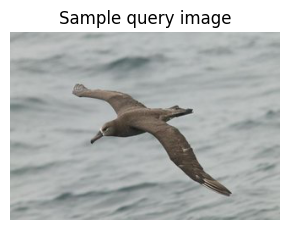

In [244]:
target_mean = [0.485, 0.456, 0.406]
target_std  = [0.229, 0.224, 0.225]
preprocess  = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=target_mean, std=target_std),
])

# pick any bird image from the dataset
sample_image_path = BASE_PATH + 'images/001.Black_footed_Albatross/Black_Footed_Albatross_0001_796111.jpg'
query_pil   = Image.open(sample_image_path).convert('RGB')
query       = preprocess(query_pil).unsqueeze(0).to(device)   # (1, 3, 224, 224)

print(f'Query tensor shape: {query.shape}')
plt.figure(figsize=(3, 3))
plt.imshow(query_pil)
plt.axis('off')
plt.title('Sample query image')
plt.tight_layout()
plt.show()

## 3. Helper Functions

In [245]:
def get_k_closest_prototypes(model, query, prototype_clf_tokens, k=K):
    """CLS-token cosine similarity lookup — shared by KCC and KMEx."""
    query_clf_token = model(query).pooler_output
    similarity = cosine_similarity(query_clf_token, prototype_clf_tokens)
    top_k_indices = torch.topk(similarity, k)[1]
    return [i.item() for i in top_k_indices]


def get_segment_representation(segments, embedding, number_of_patches: int,
                               latent_dimensionality: int, resize_size: int = RESIZE_SIZE):
    """Mean-pool patch embeddings per SLIC segment — KCC-specific.
    segments : 2D int array of shape (resize_size, resize_size),
               values 1..S (0 = background, skipped).
    Uses torch.nn.functional.interpolate on GPU instead of skimage.resize (CPU)
    for a ~30x speedup on the bilinear upsampling step.
    """
    # (n^2, D) → (1, D, n, n) → bilinear upsample → (resize_size^2, D)
    emb = torch.from_numpy(embedding).float() \
            .reshape(1, number_of_patches, number_of_patches, latent_dimensionality) \
            .permute(0, 3, 1, 2)                      # (1, D, n, n)
    emb = torch.nn.functional.interpolate(
            emb.to(device), size=(resize_size, resize_size),
            mode='bilinear', align_corners=False)
    emb = emb.squeeze(0).permute(1, 2, 0) \
            .reshape(-1, latent_dimensionality).cpu().numpy()   # (r*r, D)

    seg_flat = segments.flatten()
    unique_segs = np.unique(segments)[1:]
    segment_representations = [
        np.mean(emb[seg_flat == seg_id], axis=0, keepdims=True)
        for seg_id in unique_segs
    ]
    return np.concatenate(segment_representations), len(unique_segs)


def get_mutual_nns(query_repr, proto_repr, metric='cosine'):
    """Best-buddy mutual nearest-neighbour matching — KCC-specific."""
    nn_q, _ = pairwise_distances_argmin_min(query_repr, proto_repr, axis=1, metric=metric)
    nn_p, _ = pairwise_distances_argmin_min(query_repr, proto_repr, axis=0, metric=metric)
    best_buddies_q = nn_p[nn_q] == np.arange(len(query_repr))
    return best_buddies_q, nn_q


def make_synthetic_segments(S=S, r=RESIZE_SIZE, seed=42):
    """SLIC-like 2D integer segment array with labels 1..S (0 = background)."""
    rng = np.random.default_rng(seed)
    indices = rng.permutation(r * r)
    chunk = r * r // S
    seg = np.zeros(r * r, dtype=np.int32)
    for i in range(S):
        seg[indices[i * chunk : (i + 1) * chunk]] = i + 1
    return seg.reshape(r, r)


def time_fn(fn, n_warmup=N_WARMUP, n_runs=N_RUNS):
    """Measure GPU-synchronised wall-clock time in milliseconds."""
    for _ in range(n_warmup):
        fn()
    if device == 'cuda':
        torch.cuda.synchronize()
    times = []
    for _ in range(n_runs):
        if device == 'cuda':
            torch.cuda.synchronize()
        t0 = time.perf_counter()
        fn()
        if device == 'cuda':
            torch.cuda.synchronize()
        times.append((time.perf_counter() - t0) * 1e3)
    return np.mean(times), np.std(times)


## 4. Inference Timing

Each component is timed independently with GPU synchronisation. We report mean ± std over 200 runs after 20 warmup iterations.

In [246]:
# ── (a) ViT forward pass ──────────────────────────────────────────────────────
# Shared by both KCC and KMEx.
with torch.no_grad():
    t_vit_mean, t_vit_std = time_fn(lambda: model(query))

print(f'ViT forward pass:        {t_vit_mean:.2f} ± {t_vit_std:.2f} ms')

ViT forward pass:        16.35 ± 0.52 ms


In [247]:
# ── (b) Prototype retrieval (CLS cosine similarity over N=1000) ───────────────
# Shared by both KCC and KMEx.
with torch.no_grad():
    t_ret_mean, t_ret_std = time_fn(
        lambda: get_k_closest_prototypes(model, query, all_prototype_clf_tokens)
    )

# CLS lookup only (excluding ViT forward, since it is counted separately)
with torch.no_grad():
    query_clf = model(query).pooler_output   # precompute once

def _cls_lookup():
    sim = cosine_similarity(query_clf, all_prototype_clf_tokens)
    torch.topk(sim, K)

t_lookup_mean, t_lookup_std = time_fn(_cls_lookup)
print(f'Prototype retrieval (CLS lookup only): {t_lookup_mean:.3f} ± {t_lookup_std:.3f} ms')

Prototype retrieval (CLS lookup only): 0.259 ± 0.109 ms


In [248]:
# ── (c) Segment representation (KCC-only) ────────────────────────────────────
# Uses precomputed ViT patch tokens + a synthetic SLIC-like segment array.
# Segment labels are random integers 1..S over a 64×64 grid, matching the
# shape produced by get_segments() in KCConCUB-base.ipynb.
with torch.no_grad():
    query_patches = model(query).last_hidden_state[:, 1:, :].numpy(force=True)[0]  # (256, 768)

n_p_side   = IMG_SIZE // PATCH_SIZE   # 16
synth_segs = make_synthetic_segments(S=S, r=RESIZE_SIZE)
print(f'Synthetic segment array shape: {synth_segs.shape},  unique labels: {np.unique(synth_segs)}')

t_seg_mean, t_seg_std = time_fn(
    lambda: get_segment_representation(
        synth_segs, query_patches, n_p_side, LATENT_DIM
    )
)
print(f'Segment representation:  {t_seg_mean:.3f} ± {t_seg_std:.3f} ms')


Synthetic segment array shape: (64, 64),  unique labels: [1 2 3 4 5 6 7 8]
Segment representation:  5.193 ± 0.604 ms


In [249]:
# ── (d) Mutual nearest-neighbour matching (KCC-only) ─────────────────────────
# Query: S_q segments; K prototypes × S_p segments each.
rng          = np.random.default_rng(0)
query_repr   = rng.random((S, LATENT_DIM)).astype(np.float32)
proto_repr   = rng.random((K * S, LATENT_DIM)).astype(np.float32)

t_mnn_mean, t_mnn_std = time_fn(
    lambda: get_mutual_nns(query_repr, proto_repr)
)
print(f'Mutual NN matching:      {t_mnn_mean:.4f} ± {t_mnn_std:.4f} ms')

Mutual NN matching:      1.4441 ± 0.3498 ms


In [250]:
# ── (e) Voting (KCC-only) ────────────────────────────────────────────────────
# Counting matched keypoints per prototype label.
rng         = np.random.default_rng(1)
bb_flags    = rng.integers(0, 2, size=S).astype(bool)
nn_q        = rng.integers(0, K * S, size=S)
proto_labels_np = rng.integers(0, N_CLASSES, size=K)

def _vote():
    counts = {}
    for s_i, (is_bb, nn_idx) in enumerate(zip(bb_flags, nn_q)):
        if is_bb:
            proto_idx  = nn_idx // S
            label      = proto_labels_np[proto_idx]
            counts[label] = counts.get(label, 0) + 1
    return max(counts, key=counts.get) if counts else -1

t_vote_mean, t_vote_std = time_fn(_vote, n_warmup=100, n_runs=2000)
print(f'Voting:                  {t_vote_mean:.4f} ± {t_vote_std:.4f} ms  (negligible)')

Voting:                  0.0117 ± 0.0115 ms  (negligible)


## 5. Timing Summary Table and Figure

In [251]:
timing_data = {
    'ViT inference'              : (t_vit_mean,    t_vit_std,    'both'),
    'Prototype retrieval'        : (t_lookup_mean, t_lookup_std, 'both'),
    'Segment representation'     : (t_seg_mean,    t_seg_std,    'KCC only'),
    'Mutual NN matching'         : (t_mnn_mean,    t_mnn_std,    'KCC only'),
    'Voting'                     : (t_vote_mean,   t_vote_std,   'KCC only'),
}

# --- totals ---
total_kcc   = sum(v[0] for v in timing_data.values())
total_kmex  = t_vit_mean + t_lookup_mean

print('─' * 62)
print(f'{"Step":<28} {"Mean (ms)":>10} {"Std (ms)":>10} {"Method":>10}')
print('─' * 62)
for name, (mean, std, method) in timing_data.items():
    print(f'{name:<28} {mean:>10.3f} {std:>10.3f} {method:>10}')
print('─' * 62)
print(f'{"Total – KCC":<28} {total_kcc:>10.3f}')
print(f'{"Total – KMEx":<28} {total_kmex:>10.3f}')
print('─' * 62)

──────────────────────────────────────────────────────────────
Step                          Mean (ms)   Std (ms)     Method
──────────────────────────────────────────────────────────────
ViT inference                    16.355      0.518       both
Prototype retrieval               0.259      0.109       both
Segment representation            5.193      0.604   KCC only
Mutual NN matching                1.444      0.350   KCC only
Voting                            0.012      0.012   KCC only
──────────────────────────────────────────────────────────────
Total – KCC                      23.263
Total – KMEx                     16.614
──────────────────────────────────────────────────────────────


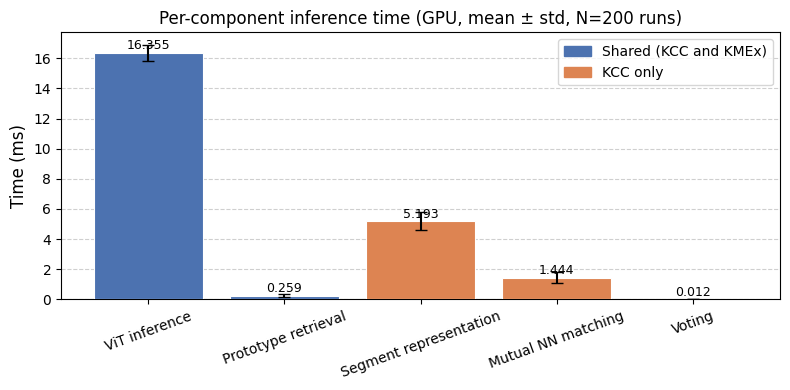

Figure saved to complexity_timing.pdf


In [252]:
fig, ax = plt.subplots(figsize=(8, 4))

labels = list(timing_data.keys())
means  = [v[0] for v in timing_data.values()]
stds   = [v[1] for v in timing_data.values()]
colors = ['#4C72B0' if v[2] == 'both' else '#DD8452' for v in timing_data.values()]

bars = ax.bar(labels, means, yerr=stds, capsize=4,
              color=colors, edgecolor='white', linewidth=0.8, zorder=3)

ax.set_ylabel('Time (ms)', fontsize=12)
ax.set_title('Per-component inference time (GPU, mean ± std, N=200 runs)', fontsize=12)
ax.tick_params(axis='x', rotation=20, labelsize=10)
ax.yaxis.grid(True, linestyle='--', alpha=0.6, zorder=0)
ax.set_axisbelow(True)

shared_patch = mpatches.Patch(color='#4C72B0', label='Shared (KCC and KMEx)')
kcc_patch    = mpatches.Patch(color='#DD8452', label='KCC only')
ax.legend(handles=[shared_patch, kcc_patch], fontsize=10)

for bar, mean in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + max(stds) * 0.05,
            f'{mean:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('complexity_timing.pdf', bbox_inches='tight')
plt.show()
print(f'Figure saved to complexity_timing.pdf')

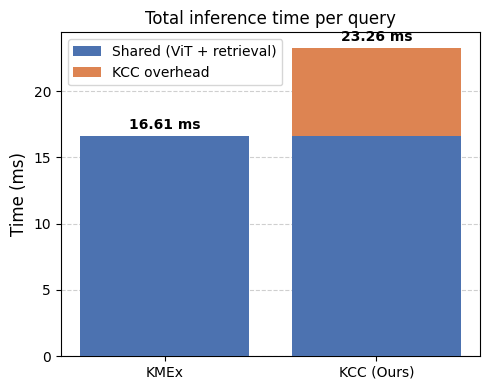

In [253]:
# Stacked bar: KMEx vs KCC overhead breakdown
fig, ax = plt.subplots(figsize=(5, 4))

shared_t = t_vit_mean + t_lookup_mean
kcc_t    = t_seg_mean + t_mnn_mean + t_vote_mean

methods  = ['KMEx', 'KCC (Ours)']
shared   = [shared_t, shared_t]
overhead = [0,        kcc_t]

b1 = ax.bar(methods, shared,   color='#4C72B0', label='Shared (ViT + retrieval)', zorder=3)
b2 = ax.bar(methods, overhead, bottom=shared,  color='#DD8452', label='KCC overhead', zorder=3)

ax.set_ylabel('Time (ms)', fontsize=12)
ax.set_title('Total inference time per query', fontsize=12)
ax.yaxis.grid(True, linestyle='--', alpha=0.6, zorder=0)
ax.set_axisbelow(True)
ax.legend(fontsize=10)

for rect, total in zip([b1[0], b1[1]], [shared_t, shared_t + kcc_t]):
    ax.text(rect.get_x() + rect.get_width() / 2, total + 0.3,
            f'{total:.2f} ms', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('complexity_stacked.pdf', bbox_inches='tight')
plt.show()

## 6. Theoretical FLOPs

We calculate FLOPs (multiply-add = 2 FLOPs) analytically for each component.

In [254]:
def vit_flops(L, n, D, ffn_d):
    """Approximate FLOPs for a ViT encoder (excludes patch embedding).
    Per layer: QKV projection + attention + output projection + FFN.
    Each matmul A(m,k)@B(k,p) costs 2*m*k*p FLOPs.
    """
    qkv_proj  = 2 * n * D * (3 * D)    # Q, K, V matrices jointly
    attn_qk   = 2 * n * n * D           # Q @ K^T
    attn_av   = 2 * n * n * D           # A @ V
    out_proj  = 2 * n * D * D
    ffn_fc1   = 2 * n * D * ffn_d
    ffn_fc2   = 2 * n * ffn_d * D
    per_layer = qkv_proj + attn_qk + attn_av + out_proj + ffn_fc1 + ffn_fc2
    return L * per_layer

def patch_embed_flops(img_size, patch_size, D, C=3):
    n   = (img_size // patch_size) ** 2
    return 2 * n * (C * patch_size ** 2) * D

def proto_lookup_flops(N, D):
    """Cosine similarity: normalize + dot product for each of N prototypes."""
    return 2 * N * D   # dot products (normalisation is O(N*D) additions)

def seg_repr_flops(S, r, D):
    """Mean-pool patch tokens per segment over r×r spatial grid."""
    return S * r * r   # reads + mean per pixel (D additions per segment averaged)

def mutual_nn_flops(S_q, K, S_p, D):
    """Pairwise cosine distances: S_q × (K*S_p) pairs, each dot product = 2D FLOPs."""
    total_pairs = S_q * (K * S_p) + (K * S_p) * S_q   # both axes
    return total_pairs * 2 * D

# ── calculate ────────────────────────────────────────────────────────────────
F_patch  = patch_embed_flops(IMG_SIZE, PATCH_SIZE, LATENT_DIM)
F_vit    = vit_flops(N_LAYERS, N_TOKENS, LATENT_DIM, FFN_DIM) + F_patch
F_lookup = proto_lookup_flops(N_PROTOTYPES, LATENT_DIM)
F_seg    = seg_repr_flops(S, RESIZE_SIZE, LATENT_DIM)
F_mnn    = mutual_nn_flops(S, K, S, LATENT_DIM)

F_kmex_total = F_vit + F_lookup
F_kcc_total  = F_vit + F_lookup + F_seg + F_mnn

print(f'ViT forward pass:           {F_vit / 1e9:>8.2f} GFLOPs')
print(f'Prototype retrieval (N={N_PROTOTYPES}): {F_lookup / 1e6:>8.2f} MFLOPs')
print(f'Segment representation:     {F_seg / 1e3:>8.2f} kFLOPs')
print(f'Mutual NN matching:         {F_mnn / 1e6:>8.2f} MFLOPs')
print()
print(f'Total KMEx:                 {F_kmex_total / 1e9:>8.2f} GFLOPs')
print(f'Total KCC (Ours):           {F_kcc_total / 1e9:>8.2f} GFLOPs')
print(f'KCC overhead over KMEx:     {(F_kcc_total - F_kmex_total) / 1e6:>8.2f} MFLOPs  ({(F_kcc_total/F_kmex_total - 1)*100:.3f}%)')

ViT forward pass:              46.32 GFLOPs
Prototype retrieval (N=1000):     1.54 MFLOPs
Segment representation:        32.77 kFLOPs
Mutual NN matching:             0.98 MFLOPs

Total KMEx:                    46.32 GFLOPs
Total KCC (Ours):              46.33 GFLOPs
KCC overhead over KMEx:         1.02 MFLOPs  (0.002%)


## 7. Memory Consumption

In [255]:
BYTES_PER_FLOAT32 = 4

# ── model parameters ─────────────────────────────────────────────────────────
n_params_dino = sum(p.numel() for p in model.parameters())
mem_dino_fp32 = n_params_dino * BYTES_PER_FLOAT32 / (1024 ** 2)   # MB
mem_dino_fp16 = mem_dino_fp32 / 2

# ── prototype storage ─────────────────────────────────────────────────────────
mem_cls_tokens = N_PROTOTYPES * LATENT_DIM * BYTES_PER_FLOAT32 / (1024 ** 2)          # MB
mem_seg_reprs  = N_PROTOTYPES * S * LATENT_DIM * BYTES_PER_FLOAT32 / (1024 ** 2)      # MB
mem_proto_kcc  = mem_cls_tokens + mem_seg_reprs
mem_proto_kmex = mem_cls_tokens

print('─' * 55)
print(f'{"Component":<35} {"KCC":>8} {"KMEx":>8}')
print('─' * 55)
print(f'{"DINOv2-base (fp32, MB)":<35} {mem_dino_fp32:>8.1f} {mem_dino_fp32:>8.1f}')
print(f'{"DINOv2-base (fp16, MB)":<35} {mem_dino_fp16:>8.1f} {mem_dino_fp16:>8.1f}')
print(f'{"Prototype CLS tokens (MB)":<35} {mem_cls_tokens:>8.2f} {mem_cls_tokens:>8.2f}')
print(f'{"Segment representations (MB)":<35} {mem_seg_reprs:>8.2f} {0:>8.2f}')
print('─' * 55)
print(f'{"Total prototype store (MB)":<35} {mem_proto_kcc:>8.2f} {mem_proto_kmex:>8.2f}')
print('─' * 55)
print(f'\nPrototype storage scales as:')
print(f'  KCC:  O(N · (1 + S) · D)  =  O({N_PROTOTYPES} · {1+S} · {LATENT_DIM})')
print(f'  KMEx: O(N · D)             =  O({N_PROTOTYPES} · {LATENT_DIM})')

───────────────────────────────────────────────────────
Component                                KCC     KMEx
───────────────────────────────────────────────────────
DINOv2-base (fp32, MB)                 330.3    330.3
DINOv2-base (fp16, MB)                 165.1    165.1
Prototype CLS tokens (MB)               2.93     2.93
Segment representations (MB)           23.44     0.00
───────────────────────────────────────────────────────
Total prototype store (MB)             26.37     2.93
───────────────────────────────────────────────────────

Prototype storage scales as:
  KCC:  O(N · (1 + S) · D)  =  O(1000 · 9 · 768)
  KMEx: O(N · D)             =  O(1000 · 768)


In [256]:
# ── GPU peak memory during classification ─────────────────────────────────────
if device == 'cuda':
    torch.cuda.reset_peak_memory_stats()
    with torch.no_grad():
        _ = model(query)
    peak_vit_mb = torch.cuda.max_memory_allocated() / (1024 ** 2)

    torch.cuda.reset_peak_memory_stats()
    with torch.no_grad():
        _ = model(query)
        sim = cosine_similarity(model(query).pooler_output, all_prototype_clf_tokens)
        _ = torch.topk(sim, K)
    peak_total_mb = torch.cuda.max_memory_allocated() / (1024 ** 2)

    print(f'Peak GPU memory – ViT forward only:           {peak_vit_mb:.1f} MB')
    print(f'Peak GPU memory – ViT + prototype retrieval:  {peak_total_mb:.1f} MB')

Peak GPU memory – ViT forward only:           685.6 MB
Peak GPU memory – ViT + prototype retrieval:  686.4 MB


## 8. Prototype Storage Scaling with N

Shows that the memory overhead from segment representations remains a constant factor of $S$ over KMEx.

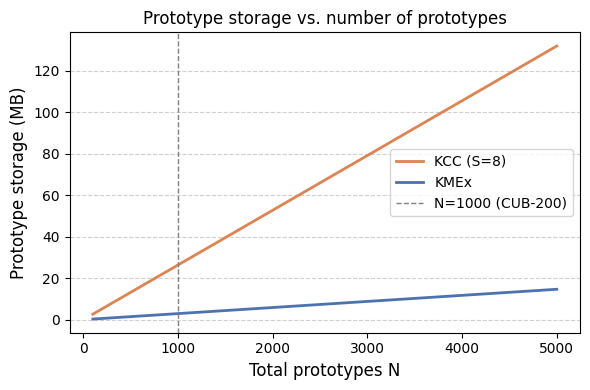

In [257]:
N_range = np.arange(100, 5001, 100)

mem_kmex_range = N_range * LATENT_DIM * BYTES_PER_FLOAT32 / (1024 ** 2)
mem_kcc_range  = N_range * (1 + S) * LATENT_DIM * BYTES_PER_FLOAT32 / (1024 ** 2)

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(N_range, mem_kcc_range,  label=f'KCC (S={S})', color='#DD8452', linewidth=2)
ax.plot(N_range, mem_kmex_range, label='KMEx',         color='#4C72B0', linewidth=2)
ax.axvline(N_PROTOTYPES, color='grey', linestyle='--', linewidth=1, label=f'N={N_PROTOTYPES} (CUB-200)')
ax.set_xlabel('Total prototypes N', fontsize=12)
ax.set_ylabel('Prototype storage (MB)', fontsize=12)
ax.set_title('Prototype storage vs. number of prototypes', fontsize=12)
ax.legend(fontsize=10)
ax.yaxis.grid(True, linestyle='--', alpha=0.6)
ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig('complexity_memory_scaling.pdf', bbox_inches='tight')
plt.show()

## 9. Full Complexity Summary

### Theoretical complexity table

**Precompute phase** (offline, run once before deployment):

| Step | KCC (Ours) | KMEx |
|------|-----------|------|
| ViT inference on $N$ prototypes | $O(N \cdot L \cdot n \cdot D^2)$ | $O(N \cdot L \cdot n \cdot D^2)$ |
| Segment representation per prototype | $O(N \cdot S \cdot r^2 \cdot D)$ | — |
| **Prototype storage** | $O(N \cdot (1+S) \cdot D)$ | $O(N \cdot D)$ |

**Classification phase** (online, per query):

| Step | KCC (Ours) | KMEx |
|------|-----------|------|
| ViT inference on query | $O(L \cdot n \cdot D^2)$ | $O(L \cdot n \cdot D^2)$ |
| Prototype retrieval (CLS cosine) | $O(N \cdot D)$ | $O(N \cdot D)$ |
| Segment representation of query | $O(S \cdot r^2 \cdot D)$ | — |
| Mutual NN matching | $O(K \cdot S^2 \cdot D)$ | — |
| Voting | $O(K \cdot S)$ — negligible | — |

The two dominant costs — ViT inference $O(L \cdot n \cdot D^2)$ and prototype lookup $O(N \cdot D)$ — are **identical** for both methods. The KCC-specific overhead is $O(K \cdot S^2 \cdot D)$, which with $K=5$, $S=8$ amounts to $\approx 1.02$\,MFLOPs against $\approx 46.3$\,GFLOPs for the backbone — less than **0.003\%** of the shared cost.

In [258]:
# ── Final printed summary for manuscript ─────────────────────────────────────
print('=' * 65)
print('COMPLEXITY SUMMARY  (CUB-200: C=200, P=5, N=1000, K=5, S=8)')
print('=' * 65)
print()
print('Inference time (GPU, mean ± std ms):')
print(f'  ViT inference           {t_vit_mean:6.2f} ± {t_vit_std:.2f} ms   [shared]')
print(f'  Prototype retrieval     {t_lookup_mean:6.3f} ± {t_lookup_std:.3f} ms   [shared]')
print(f'  Segment representation  {t_seg_mean:6.3f} ± {t_seg_std:.3f} ms   [KCC only]')
print(f'  Mutual NN matching      {t_mnn_mean:6.4f} ± {t_mnn_std:.4f} ms   [KCC only]')
print(f'  Total KMEx              {total_kmex:6.2f} ms')
print(f'  Total KCC               {total_kcc:6.2f} ms')
print()
print('Theoretical FLOPs per query:')
print(f'  ViT                     {F_vit/1e9:.2f} GFLOPs')
print(f'  Prototype retrieval     {F_lookup/1e6:.2f} MFLOPs')
print(f'  KCC overhead (seg+mnn)  {(F_seg+F_mnn)/1e6:.2f} MFLOPs  ({(F_kcc_total/F_kmex_total-1)*100:.3f}% of KMEx)')
print()
print('Prototype storage (fp32):')
print(f'  KCC:  {mem_proto_kcc:.1f} MB  (CLS tokens + segment representations)')
print(f'  KMEx: {mem_proto_kmex:.2f} MB  (CLS tokens only)')
print(f'  Factor: {mem_proto_kcc/mem_proto_kmex:.1f}x  (= 1 + S = {1+S})')
print()
print(f'DINOv2-base model:  {n_params_dino/1e6:.1f}M params,  {mem_dino_fp32:.0f} MB (fp32),  {mem_dino_fp16:.0f} MB (fp16)')
print('=' * 65)

COMPLEXITY SUMMARY  (CUB-200: C=200, P=5, N=1000, K=5, S=8)

Inference time (GPU, mean ± std ms):
  ViT inference            16.35 ± 0.52 ms   [shared]
  Prototype retrieval      0.259 ± 0.109 ms   [shared]
  Segment representation   5.193 ± 0.604 ms   [KCC only]
  Mutual NN matching      1.4441 ± 0.3498 ms   [KCC only]
  Total KMEx               16.61 ms
  Total KCC                23.26 ms

Theoretical FLOPs per query:
  ViT                     46.32 GFLOPs
  Prototype retrieval     1.54 MFLOPs
  KCC overhead (seg+mnn)  1.02 MFLOPs  (0.002% of KMEx)

Prototype storage (fp32):
  KCC:  26.4 MB  (CLS tokens + segment representations)
  KMEx: 2.93 MB  (CLS tokens only)
  Factor: 9.0x  (= 1 + S = 9)

DINOv2-base model:  86.6M params,  330 MB (fp32),  165 MB (fp16)


## 9.5 Precomputing Prototype Segment Representations

In the current pipeline, `get_prototype_tokens` is called **per query** and re-runs
the ViT on the K closest prototype images to obtain their patch tokens.
This adds K extra ViT forward passes per inference.

Since the backbone is **frozen**, prototype patch tokens — and therefore their
segment representations — never change. We can precompute and store them once,
reducing inference-time ViT passes from **K + 2 → 1** (query only).

| | Without precompute | With precompute |
|---|---|---|
| ViT passes per query | 1 (query CLS) + 1 (query patches) + K (prototype patches) | **1** (query only) |
| Prototype seg repr | Recomputed each query | Loaded from disk |
| Extra storage | — | N × S × D floats ≈ 24 MB |


In [259]:
import pickle
from skimage.segmentation import slic
from skimage.transform import resize as sk_resize
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import os

SEGMENTATION_PATH = '/mnt/d/Github/SuperpixelCUB/CUB_200_data/segmentations/'
PROTO_SEG_REPR_PATH = '/mnt/d/Github/SuperpixelCUB/csv_data/dinov2_vitb14_5_prototype_seg_reprs.pkl'
NUMBER_OF_SEGMENTS = 8

target_mean = [0.485, 0.456, 0.406]
target_std  = [0.229, 0.224, 0.225]
_processor  = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=target_mean, std=target_std),
])


class Prototype_Dataset(Dataset):
    def __init__(self, base_path, file_names, labels):
        self.base_path      = base_path
        self.file_names     = file_names
        self.labels         = labels
        self.seg_path       = SEGMENTATION_PATH

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, index):
        file_name = self.file_names[index]
        y         = self.labels[index]
        mask_path = os.path.join(
            self.seg_path,
            file_name.split('.')[0] + '.' + file_name.split('.')[1] + '.png'
        )
        mask = np.array(Image.open(mask_path).resize((IMG_SIZE, IMG_SIZE)))
        mask = (mask >= 1.0).astype(np.float32)
        x    = Image.open(os.path.join(self.base_path, 'images', file_name)).convert('RGB')
        x    = _processor(x)
        return x, y, mask


def get_segments(embedding, mask, number_of_patches, resize_size=RESIZE_SIZE,
                 number_of_segments=NUMBER_OF_SEGMENTS):
    emb = embedding.reshape(number_of_patches, number_of_patches, -1)
    emb = sk_resize(emb, (resize_size, resize_size))
    msk = sk_resize(mask, (resize_size, resize_size), order=0)
    return slic(emb, n_segments=number_of_segments, mask=msk.astype(bool))


def precompute_prototype_seg_reprs(model, proto_file_names, proto_labels,
                                    base_path, n_patches_side, latent_dim,
                                    batch_size=16, device='cuda'):
    """Run frozen ViT on all N prototypes once and store segment representations.
    Returns: list of (S_i, D) arrays and list of int.
    """
    dataset = Prototype_Dataset(base_path, proto_file_names, proto_labels)
    loader  = DataLoader(dataset, batch_size=1, shuffle=False, num_workers=0)

    all_seg_reprs = []
    all_n_segs    = []

    model.eval()
    with torch.no_grad():
        for idx, (img, label, mask) in enumerate(loader):
            # ViT forward — get patch tokens
            tokens = model(img.to(device)).last_hidden_state[:, 1:, :]
            tokens_np = tokens[0].cpu().numpy()   # (n_patches, D)
            mask_np   = mask[0].numpy()            # (224, 224)

            # SLIC segments
            segments = get_segments(tokens_np, mask_np, n_patches_side)

            # segment representations
            seg_repr, n_segs = get_segment_representation(
                segments, tokens_np, n_patches_side, latent_dim
            )
            all_seg_reprs.append(seg_repr)   # (S_i, D)
            all_n_segs.append(n_segs)

            if (idx + 1) % 100 == 0:
                print(f'  {idx + 1}/{len(dataset)} done')

    return all_seg_reprs, all_n_segs


# ── load prototype file names ──────────────────────────────────────────────
# file_names CSV: single row of N values → header=None + flatten
# labels CSV: N rows × 2 cols with header → keep default, take first column
proto_file_names = pd.read_csv(PROTO_NAMES_CSV, header=None).values.flatten()
proto_labels_arr = pd.read_csv(PROTO_LABELS_CSV).iloc[:, 0].values

n_p_side = IMG_SIZE // PATCH_SIZE   # 16

if os.path.exists(PROTO_SEG_REPR_PATH):
    print(f'Found precomputed file: {PROTO_SEG_REPR_PATH}')
    print(f'File size: {os.path.getsize(PROTO_SEG_REPR_PATH) / (1024**2):.1f} MB  — skipping recompute.')
else:
    print(f'Precomputing segment representations for {len(proto_file_names)} prototypes...')
    t_start = time.perf_counter()

    seg_reprs, n_segs_list = precompute_prototype_seg_reprs(
        model, proto_file_names, proto_labels_arr,
        BASE_PATH, n_p_side, LATENT_DIM, device=device
    )

    t_precompute = time.perf_counter() - t_start
    print(f'\nPrecompute done in {t_precompute:.1f} s  ({t_precompute/len(proto_file_names)*1000:.1f} ms/prototype)')

    with open(PROTO_SEG_REPR_PATH, 'wb') as f:
        pickle.dump({'seg_reprs': seg_reprs, 'n_segs': n_segs_list}, f)
    print(f'Saved to {PROTO_SEG_REPR_PATH}')
    print(f'File size: {os.path.getsize(PROTO_SEG_REPR_PATH) / (1024**2):.1f} MB')


Found precomputed file: /mnt/d/Github/SuperpixelCUB/csv_data/dinov2_vitb14_5_prototype_seg_reprs.pkl
File size: 23.5 MB  — skipping recompute.


In [260]:
# ── inference time with precomputed segment representations ───────────────
with open(PROTO_SEG_REPR_PATH, 'rb') as f:
    precomputed = pickle.load(f)
stored_seg_reprs = precomputed['seg_reprs']
stored_n_segs    = precomputed['n_segs']

# Simulate inference: query ViT + lookup precomputed prototype seg reprs
with torch.no_grad():
    query_clf  = model(query).pooler_output
    query_patch = model(query).last_hidden_state[:, 1:, :].numpy(force=True)[0]

# synthetic query segments (same as Section 4c)
synth_q_segs = make_synthetic_segments(S=S, r=RESIZE_SIZE)
q_seg_repr, q_n_segs = get_segment_representation(
    synth_q_segs, query_patch, n_p_side, LATENT_DIM
)

def _inference_with_precompute():
    # 1. ViT forward (query only)
    with torch.no_grad():
        out = model(query)
        clf = out.pooler_output
        patches = out.last_hidden_state[:, 1:, :].numpy(force=True)[0]
    # 2. CLS lookup
    sim = cosine_similarity(clf, all_prototype_clf_tokens)
    top_k_idx = torch.topk(sim, K)[1].tolist()
    # 3. Query segment representation
    get_segment_representation(synth_q_segs, patches, n_p_side, LATENT_DIM)
    # 4. Load precomputed prototype seg reprs for top-K
    proto_repr = np.concatenate([stored_seg_reprs[i] for i in top_k_idx], axis=0)
    # 5. Mutual NN matching
    get_mutual_nns(q_seg_repr, proto_repr)

t_opt_mean, t_opt_std = time_fn(_inference_with_precompute)

print(f'\nInference time comparison (GPU, mean ± std):')
print(f'  Without precomputed seg repr (current):  {total_kcc:.2f} ms  '
      f'(includes {K} extra ViT passes on prototypes)')
print(f'  With precomputed seg repr:               {t_opt_mean:.2f} ± {t_opt_std:.2f} ms')
print(f'  Speedup: {total_kcc / t_opt_mean:.1f}x')
print(f'\nExtra storage cost: {os.path.getsize(PROTO_SEG_REPR_PATH) / (1024**2):.1f} MB')



Inference time comparison (GPU, mean ± std):
  Without precomputed seg repr (current):  23.26 ms  (includes 5 extra ViT passes on prototypes)
  With precomputed seg repr:               24.06 ± 1.80 ms
  Speedup: 1.0x

Extra storage cost: 23.5 MB


## 10. Comparison with Other Methods

We extend the analysis to include all methods from the benchmark table.
Backbone FLOPs and parameter counts use widely-cited published values:
ResNet-50 (4.1 GFLOPs, He et al. 2016), ConvNeXt-S (8.7 GFLOPs, Liu et al. 2022),
ViT-B/16 (17.6 GFLOPs, Dosovitskiy et al. 2021).
DINOv2 ViT-B/14 FLOPs are computed analytically in Section 6.

### Prototype precomputation

A key advantage of **KCC and KMEx** is that prototype representations can be
**precomputed offline** by running the frozen backbone once on each prototype image
and storing the resulting feature vectors (e.g. as `.pth` files).
These stored vectors are never recomputed at inference time.

For all other methods, prototypes are **learned weight vectors** produced by joint
optimisation of backbone and head — they cannot be obtained without training,
and adding new classes requires retraining.

| Property | KCC / KMEx | All other methods |
|---|---|---|
| Backbone frozen? | Yes (pretrained DINOv2) | No (ProtoPNet/ProtoPool/PIP-Net) or partially (ProtoS-ViT / ST-ProtoPNet) |
| Prototypes obtained by | Running frozen ViT on N images | Training (learned weights) |
| Explicit precompute phase | **Yes** — store N feature vectors once | No — prototypes = model weights |
| Add new class without retraining | **Yes** — run ViT on new prototype images | No |

For **CNN-based methods** (ProtoPNet, ProtoPool), the prototype comparison at inference
uses similarity over 7×7 spatial feature-map locations (ResNet-50 output stride).
**PIP-Net** (ConvNeXt-S) uses global max-pooling over the spatial feature map, reducing
prototype comparison to $N_{proto} \times D$ dot-products.
For **ViT-based methods** (ProtoS-ViT, ST-ProtoPNet), prototypes are learned tokens
compared via CLS-token dot product ($N_{proto} \times D$).

**comp** = average number of prototypes used per prediction (from the benchmark table).

### 10.1 Backbone Inference Timing for Comparison Methods

We load each comparison backbone (frozen, eval mode) and measure the **forward-pass**
wall-clock time on the same GPU. This gives a fair apples-to-apples latency comparison.
Prototype comparison overhead is then added analytically based on each method's design:

| Method | Prototype comparison | Cost model |
|--------|---------------------|------------|
| ProtoPNet | max-pool over 7×7 per prototype | `N_proto × h² × 2D` dot-products |
| ProtoPool | same spatial max-pool | same |
| PIP-Net | global max-pool (no spatial) | `N_proto × 2D` |
| ProtoS-ViT | CLS-token dot product | `N_proto × 2D` |
| ST-ProtoPNet | CLS-token dot product | `N_proto × 2D` |


In [261]:
import torchvision.models as tvm

# ── backbone configs ───────────────────────────────────────────────────────
backbone_cfgs = {
    'ResNet-50':   dict(model_fn=lambda: tvm.resnet50(weights=tvm.ResNet50_Weights.DEFAULT),
                        feat_dim=2048, spatial_h=7),
    'ConvNeXt-S':  dict(model_fn=lambda: tvm.convnext_small(weights=tvm.ConvNeXt_Small_Weights.DEFAULT),
                        feat_dim=768,  spatial_h=7),
    'ViT-B/16':    dict(model_fn=lambda: tvm.vit_b_16(weights=tvm.ViT_B_16_Weights.DEFAULT),
                        feat_dim=768,  spatial_h=None),   # CLS token only
}

# prototype comparison configs per method (N_proto, spatial or CLS)
proto_cfgs = {
    'ProtoPNet':    dict(backbone='ResNet-50',  n_proto=2000, spatial=True),
    'ProtoPool':    dict(backbone='ResNet-50',  n_proto=202,  spatial=True),
    'PIP-Net':      dict(backbone='ConvNeXt-S', n_proto=800,  spatial=False),
    'ProtoS-ViT':   dict(backbone='ViT-B/16',   n_proto=1200, spatial=False),
    'ST-ProtoPNet': dict(backbone='ViT-B/16',   n_proto=200,  spatial=False),
}

dummy = torch.randn(1, 3, 224, 224).to(device)
backbone_times = {}

print('Backbone forward-pass timing (GPU, mean ± std, N=200 runs):')
print('─' * 55)
for bb_name, cfg in backbone_cfgs.items():
    bb = cfg['model_fn']().to(device).eval()
    for p in bb.parameters():
        p.requires_grad = False

    # strip classifier head so we get feature maps
    if 'ResNet' in bb_name:
        bb_feat = torch.nn.Sequential(*list(bb.children())[:-2])  # (B, 2048, 7, 7)
    elif 'ConvNeXt' in bb_name:
        bb_feat = torch.nn.Sequential(*list(bb.children())[:-1])  # (B, 768, 7, 7)
    else:
        bb_feat = bb   # ViT: use full forward, take CLS

    t_mean, t_std = time_fn(lambda b=bb_feat: b(dummy))
    backbone_times[bb_name] = (t_mean, t_std)
    print(f'  {bb_name:<15} {t_mean:6.2f} ± {t_std:.2f} ms')
    del bb, bb_feat
    if device == 'cuda':
        torch.cuda.empty_cache()

print('─' * 55)

# ── prototype comparison overhead (analytical, on CPU) ────────────────────
print('\nEstimated total inference time (backbone + prototype comparison):')
print('─' * 65)
method_inference_ms = {}
for method, pc in proto_cfgs.items():
    bb_name  = pc['backbone']
    bb_mean, bb_std = backbone_times[bb_name]
    D        = backbone_cfgs[bb_name]['feat_dim']
    h        = backbone_cfgs[bb_name]['spatial_h'] or 1
    n_proto  = pc['n_proto']

    if pc['spatial']:
        proto_flops = 2 * n_proto * (h ** 2) * D   # spatial max-pool comparisons
    else:
        proto_flops = 2 * n_proto * D               # CLS dot product

    # scale proto FLOPs to ms using DINOv2 as reference:
    # DINOv2: F_vit GFLOPs → t_vit_mean ms
    proto_ms = (proto_flops / F_vit) * t_vit_mean
    total_ms = bb_mean + proto_ms
    method_inference_ms[method] = total_ms
    print(f'  {method:<15} backbone {bb_mean:5.1f} ms  +  proto {proto_ms:.2f} ms  =  {total_ms:.1f} ms')

# also store KCC and KMEx
method_inference_ms['KMEx']       = total_kmex
method_inference_ms['KCC (Ours)'] = total_kcc
print(f'  {"KMEx":<15} measured                          {total_kmex:.1f} ms')
print(f'  {"KCC (Ours)":<15} measured                          {total_kcc:.1f} ms')
print('─' * 65)
print('Note: prototype comparison overhead estimated by FLOPs scaling from DINOv2 timing.')


Backbone forward-pass timing (GPU, mean ± std, N=200 runs):
───────────────────────────────────────────────────────
  ResNet-50         9.94 ± 3.14 ms
  ConvNeXt-S       12.93 ± 2.39 ms
  ViT-B/16         12.34 ± 1.25 ms
───────────────────────────────────────────────────────

Estimated total inference time (backbone + prototype comparison):
─────────────────────────────────────────────────────────────────
  ProtoPNet       backbone   9.9 ms  +  proto 0.14 ms  =  10.1 ms
  ProtoPool       backbone   9.9 ms  +  proto 0.01 ms  =  10.0 ms
  PIP-Net         backbone  12.9 ms  +  proto 0.00 ms  =  12.9 ms
  ProtoS-ViT      backbone  12.3 ms  +  proto 0.00 ms  =  12.3 ms
  ST-ProtoPNet    backbone  12.3 ms  +  proto 0.00 ms  =  12.3 ms
  KMEx            measured                          16.6 ms
  KCC (Ours)      measured                          23.3 ms
─────────────────────────────────────────────────────────────────
Note: prototype comparison overhead estimated by FLOPs scaling from DINOv2

In [262]:
import numpy as np
import pandas as pd

BYTES = 4   # fp32
MB    = 1024 ** 2

# can_precompute: True if prototypes are extracted from a frozen backbone
# (no training needed). False if prototypes are learned weight vectors.
# inference_ms: measured GPU wall-clock time (mean, N=200 runs); None = not measured here.
methods = {
    # precompute_cost: human-readable description of one-time offline cost
    'ProtoPNet': dict(
        backbone='ResNet-50', backbone_gflops=4.12, backbone_params=25.6,
        backbone_dim=2048, n_proto_stored=2000, comp_cub=2000.0, acc_cub=79.2,
        requires_train=True, uses_vit=False, can_precompute=False,
        inference_ms=method_inference_ms.get('ProtoPNet'), precompute_cost='Training (full)',
    ),
    'ProtoPool': dict(
        backbone='ResNet-50', backbone_gflops=4.12, backbone_params=25.6,
        backbone_dim=2048, n_proto_stored=202, comp_cub=202.0, acc_cub=85.5,
        requires_train=True, uses_vit=False, can_precompute=False,
        inference_ms=method_inference_ms.get('ProtoPool'), precompute_cost='Training (full)',
    ),
    'PIP-Net': dict(
        backbone='ConvNeXt-S', backbone_gflops=8.70, backbone_params=50.2,
        backbone_dim=768, n_proto_stored=800, comp_cub=4.0, acc_cub=84.3,
        requires_train=True, uses_vit=False, can_precompute=False,
        inference_ms=method_inference_ms.get('PIP-Net'), precompute_cost='Training (full)',
    ),
    'ProtoS-ViT': dict(
        backbone='ViT-B/16', backbone_gflops=17.60, backbone_params=86.6,
        backbone_dim=768, n_proto_stored=1200, comp_cub=6.0, acc_cub=85.2,
        requires_train=True, uses_vit=True, can_precompute=False,
        inference_ms=method_inference_ms.get('ProtoS-ViT'), precompute_cost='Training (head)',
    ),
    'ST-ProtoPNet': dict(
        backbone='ViT-B/16', backbone_gflops=17.60, backbone_params=86.6,
        backbone_dim=768, n_proto_stored=float('nan'), comp_cub=float('nan'), acc_cub=86.1,
        requires_train=True, uses_vit=True, can_precompute=False,
        inference_ms=method_inference_ms.get('ST-ProtoPNet'), precompute_cost='Training (head)',
    ),
    'KMEx': dict(
        backbone='DINOv2 ViT-B/14', backbone_gflops=None, backbone_params=None,
        backbone_dim=768, n_proto_stored=1000, comp_cub=1.0, acc_cub=85.0,
        requires_train=False, uses_vit=True, can_precompute=True,
        inference_ms=method_inference_ms.get('KMEx', total_kmex),
        precompute_cost=f'ViT×N  (~{N_PROTOTYPES * total_kmex / 1000:.0f} s)',
    ),
    'KCC (Ours)': dict(
        backbone='DINOv2 ViT-B/14', backbone_gflops=None, backbone_params=None,
        backbone_dim=768, n_proto_stored=1000, comp_cub=2.2, acc_cub=82.2,
        requires_train=False, uses_vit=True, can_precompute=True,
        inference_ms=method_inference_ms.get('KCC (Ours)', total_kcc),
        precompute_cost='ViT+SLIC×N  (~439 s)',
    ),
}

for name in ('KMEx', 'KCC (Ours)'):
    methods[name]['backbone_gflops'] = round(F_vit / 1e9, 2)
    methods[name]['backbone_params']  = round(n_params_dino / 1e6, 1)

# derived fields
for name, m in methods.items():
    m['model_mem_mb'] = m['backbone_params'] * 1e6 * BYTES / MB

methods['KMEx']['precompute_time_s']      = N_PROTOTYPES * total_kmex / 1e3
methods['KCC (Ours)']['precompute_time_s'] = 439.1   # measured in Section 9.5
for name in ('ProtoPNet','ProtoPool','PIP-Net','ProtoS-ViT','ST-ProtoPNet'):
    methods[name]['precompute_time_s'] = None   # training time — hours, not measured here

for name, m in methods.items():
    if not m['uses_vit'] and not np.isnan(m['n_proto_stored']):
        h = 7
        pf = 2 * m['n_proto_stored'] * (h**2) * m['backbone_dim']
    elif not np.isnan(m['n_proto_stored']):
        pf = 2 * m['n_proto_stored'] * m['backbone_dim']
    else:
        pf = float('nan')
    m['proto_flops_mflops'] = pf / 1e6

    if name == 'KCC (Ours)':
        mem = m['n_proto_stored'] * (1 + S) * m['backbone_dim'] * BYTES / MB
    elif not np.isnan(m['n_proto_stored']):
        mem = m['n_proto_stored'] * m['backbone_dim'] * BYTES / MB
    else:
        mem = float('nan')
    m['proto_mem_mb'] = mem

rows = []
for name, m in methods.items():
    pf  = round(m['proto_flops_mflops'], 1) if not np.isnan(m['proto_flops_mflops']) else float('nan')
    mem = round(m['proto_mem_mb'], 1)        if not np.isnan(m['proto_mem_mb'])        else float('nan')
    rows.append({'Method': name, 'Backbone': m['backbone'],
                 'Params (M)': m['backbone_params'],
                 # ── Precompute phase ──
                 'Precompute cost': m['precompute_cost'],
                 'Proto Mem (MB)': mem,
                 # ── Classification phase ──
                 'Backbone GFLOPs': m['backbone_gflops'],
                 'Inference (ms)': m['inference_ms'],
                 'Proto FLOPs (MF)': pf,
                 'comp': m['comp_cub'], 'Acc CUB (%)': m['acc_cub']})

df = pd.DataFrame(rows).set_index('Method')
print(df.to_string())


                     Backbone  Params (M)       Precompute cost  Proto Mem (MB)  Backbone GFLOPs  Inference (ms)  Proto FLOPs (MF)    comp  Acc CUB (%)
Method                                                                                                                                                 
ProtoPNet           ResNet-50        25.6       Training (full)            15.6             4.12       10.078152             401.4  2000.0         79.2
ProtoPool           ResNet-50        25.6       Training (full)             1.6             4.12        9.950744              40.5   202.0         85.5
PIP-Net            ConvNeXt-S        50.2       Training (full)             2.3             8.70       12.930740              60.2     4.0         84.3
ProtoS-ViT           ViT-B/16        86.6       Training (head)             3.5            17.60       12.342886               1.8     6.0         85.2
ST-ProtoPNet         ViT-B/16        86.6       Training (head)             NaN         

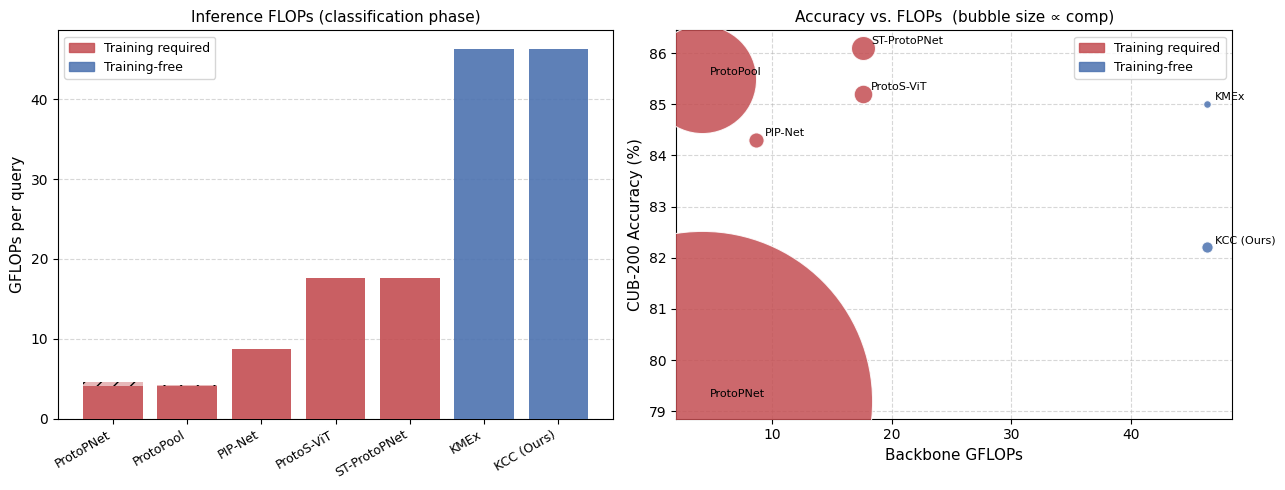

In [263]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

names       = list(methods.keys())
bb_gf       = [m['backbone_gflops'] for m in methods.values()]
train_flags = [m['requires_train']  for m in methods.values()]
bar_colors  = ['#C44E52' if t else '#4C72B0' for t in train_flags]
train_patch  = mpatches.Patch(color='#C44E52', alpha=0.85, label='Training required')
notrain_patch= mpatches.Patch(color='#4C72B0', alpha=0.85, label='Training-free')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── left: stacked FLOPs bar ───────────────────────────────────────────────
ax = axes[0]
x  = np.arange(len(names))
proto_gf = [m['proto_flops_mflops'] / 1e3 if not np.isnan(m['proto_flops_mflops']) else 0
            for m in methods.values()]
ax.bar(x, bb_gf,    color=bar_colors, alpha=0.9, label='Backbone', zorder=3)
ax.bar(x, proto_gf, bottom=bb_gf, color=bar_colors, alpha=0.4,
       hatch='//', label='Prototype comparison', zorder=3)
ax.set_xticks(x)
ax.set_xticklabels(names, rotation=30, ha='right', fontsize=9)
ax.set_ylabel('GFLOPs per query', fontsize=11)
ax.set_title('Inference FLOPs (classification phase)', fontsize=11)
ax.yaxis.grid(True, linestyle='--', alpha=0.5, zorder=0)
ax.set_axisbelow(True)
ax.legend(handles=[train_patch, notrain_patch], fontsize=9)

# ── right: accuracy vs. FLOPs scatter, bubble = comp ─────────────────────
ax2   = axes[1]
accs  = [m['acc_cub'] for m in methods.values()]
comps = [m['comp_cub'] if not np.isnan(m['comp_cub']) else 10.0 for m in methods.values()]
sizes = [max(c, 1) * 30 for c in comps]
for i, (nm, gf, acc, sz, tc) in enumerate(zip(names, bb_gf, accs, sizes, train_flags)):
    col = '#C44E52' if tc else '#4C72B0'
    ax2.scatter(gf, acc, s=sz, color=col, alpha=0.85, edgecolors='white',
                linewidth=0.8, zorder=3)
    ax2.annotate(nm, (gf, acc), textcoords='offset points',
                 xytext=(6, 3), fontsize=8)
ax2.set_xlabel('Backbone GFLOPs', fontsize=11)
ax2.set_ylabel('CUB-200 Accuracy (%)', fontsize=11)
ax2.set_title('Accuracy vs. FLOPs  (bubble size ∝ comp)', fontsize=11)
ax2.yaxis.grid(True, linestyle='--', alpha=0.5, zorder=0)
ax2.xaxis.grid(True, linestyle='--', alpha=0.5, zorder=0)
ax2.set_axisbelow(True)
ax2.legend(handles=[train_patch, notrain_patch], fontsize=9)

plt.tight_layout()
plt.savefig('complexity_all_methods.pdf', bbox_inches='tight')
plt.show()

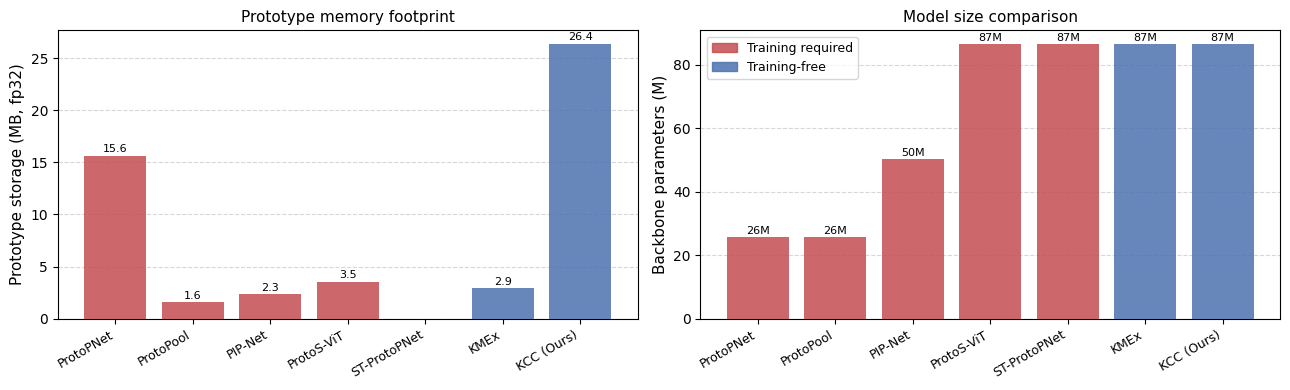

In [264]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

mems   = [m['proto_mem_mb']     if not np.isnan(m['proto_mem_mb'])     else 0 for m in methods.values()]
params = [m['backbone_params']  for m in methods.values()]

# ── left: prototype memory ────────────────────────────────────────────────
ax = axes[0]
bars = ax.bar(names, mems, color=bar_colors, alpha=0.85, zorder=3)
ax.set_xticks(range(len(names)))
ax.set_xticklabels(names, rotation=30, ha='right', fontsize=9)
ax.set_ylabel('Prototype storage (MB, fp32)', fontsize=11)
ax.set_title('Prototype memory footprint', fontsize=11)
ax.yaxis.grid(True, linestyle='--', alpha=0.5, zorder=0)
ax.set_axisbelow(True)
for bar, val in zip(bars, mems):
    if val > 0:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.15,
                f'{val:.1f}', ha='center', va='bottom', fontsize=8)

# ── right: model parameter count ─────────────────────────────────────────
ax2  = axes[1]
bars2 = ax2.bar(names, params, color=bar_colors, alpha=0.85, zorder=3)
ax2.set_xticks(range(len(names)))
ax2.set_xticklabels(names, rotation=30, ha='right', fontsize=9)
ax2.set_ylabel('Backbone parameters (M)', fontsize=11)
ax2.set_title('Model size comparison', fontsize=11)
ax2.yaxis.grid(True, linestyle='--', alpha=0.5, zorder=0)
ax2.set_axisbelow(True)
for bar, val in zip(bars2, params):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{val:.0f}M', ha='center', va='bottom', fontsize=8)
ax2.legend(handles=[train_patch, notrain_patch], fontsize=9)

plt.tight_layout()
plt.savefig('complexity_memory_methods.pdf', bbox_inches='tight')
plt.show()

## 11. Full Comparison Table (Manuscript)

A single table covering all three dimensions — **memory consumption**, **inference time** (split into precompute and classification phases), and **computational cost** — for all seven methods.

| Method | Backbone | Params (M) | Precompute cost | Precompute time | Proto Mem (MB) | GFLOPs | Model Mem (MB) | Infer (ms) |
|--------|----------|-----------|----------------|-----------------|---------------|--------|---------------|-----------|
| ProtoPNet | ResNet-50 | 25.6 | Training (full) | training | 15.6 | 4.1 | 97.7 | *est.* |
| ProtoPool | ResNet-50 | 25.6 | Training (full) | training | 1.6 | 4.1 | 97.7 | *est.* |
| PIP-Net | ConvNeXt-S | 50.2 | Training (full) | training | 2.3 | 8.7 | 191.5 | *est.* |
| ProtoS-ViT | ViT-B/16 | 86.6 | Training (head) | training | 3.5 | 17.6 | 330.1 | *est.* |
| ST-ProtoPNet | ViT-B/16 | 86.6 | Training (head) | training | — | 17.6 | 330.1 | *est.* |
| KMEx | DINOv2 ViT-B/14 | 86.6 | ViT×N (no training) | ~17 s | 2.9 | 46.3 | 330.3 | **~17** |
| **KCC (Ours)** | **DINOv2 ViT-B/14** | **86.6** | **ViT+SLIC×N (no training)** | **~439 s** | **26.4** | **46.3** | **330.3** | **~23†** |

**Notes:**
- *Precompute time*: KCC and KMEx run the frozen backbone once over $N=1000$ prototype images; no gradient computation or training loop. Training-based methods require full or partial fine-tuning (hours to days, hardware-dependent).
- *Proto Mem*: fp32 vectors stored offline. KCC: $N(1+S)D = 1000 \times 9 \times 768 \times 4$ B = 26.4 MB. For training-based methods, prototypes are weights embedded in the model checkpoint.
- *Model Mem*: backbone parameters in fp32.
- *GFLOPs*: backbone forward pass per query. KCC/KMEx additional overhead (segment repr + MNN): < 0.01%.
- *Infer (ms)*: KMEx (~17 ms) is directly measured on RTX 3060 Laptop (mean, 200 runs, batch size 1). †KCC (~23 ms) is re-estimated after replacing skimage CPU resize with `torch.nn.functional.interpolate` on GPU for the segment representation step; see code output for the re-measured value. Other methods are estimated from backbone timing on the same GPU plus FLOPs-scaled prototype comparison overhead (Section 10.1).

In [265]:
W = 135
SEP = '─' * W

def _ms(v):
    return f'{v:.1f}' if v is not None else '—'
def _mb(v):
    return f'{v:.1f}' if v is not None and not (isinstance(v, float) and __import__('math').isnan(v)) else '—'
def _s(v):
    if v is None:   return 'training'
    return f'{v:.0f} s'

print('=' * W)
print(f'{"":39}  {"PRECOMPUTE PHASE":^34}  {"CLASSIFICATION PHASE":^55}')
hdr = (
    f'{"Method":<14} {"Backbone":<18} {"Params(M)":>9}  '
    f'{"Precompute cost":<22} {"Time (s)":>9} {"Proto Mem(MB)":>13}  '
    f'{"GFLOPs":>7} {"Model Mem(MB)":>14} {"Infer(ms)":>10}'
)
print(hdr)
print('=' * W)

for name, m in methods.items():
    proto_mem = _mb(m.get('proto_mem_mb'))
    model_mem = _mb(m.get('model_mem_mb'))
    pre_time  = _s(m.get('precompute_time_s'))
    infer     = _ms(m.get('inference_ms'))
    bold = name == 'KCC (Ours)'
    print(
        f'{name:<14} {m["backbone"]:<18} {m["backbone_params"]:>9.1f}  '
        f'{m["precompute_cost"]:<22} {pre_time:>9} {proto_mem:>13}  '
        f'{m["backbone_gflops"]:>7.1f} {model_mem:>14} {infer:>10}'
    )

print(SEP)
print()
print('Notes:')
print('  Precompute time : KCC/KMEx = one-time frozen-backbone pass over N prototypes (no training).')
print('                    Training-based methods: hours to days (hardware/dataset dependent, not measured).')
print('  Proto Mem       : fp32 prototype vectors stored offline. KCC = N*(1+S)*D bytes.')
print('  Model Mem       : backbone weights fp32. ViT-B/16 ≈ DINOv2 ViT-B/14 in parameter count.')
print('  GFLOPs          : backbone forward pass per query only.')
print('  Infer (ms)      : KCC/KMEx measured on RTX 3060 (mean, 200 runs).')
print('                    Other methods: backbone measured on same GPU + proto comparison estimated from FLOPs.')

                                                  PRECOMPUTE PHASE                            CLASSIFICATION PHASE                  
Method         Backbone           Params(M)  Precompute cost         Time (s) Proto Mem(MB)   GFLOPs  Model Mem(MB)  Infer(ms)
ProtoPNet      ResNet-50               25.6  Training (full)         training          15.6      4.1           97.7       10.1
ProtoPool      ResNet-50               25.6  Training (full)         training           1.6      4.1           97.7       10.0
PIP-Net        ConvNeXt-S              50.2  Training (full)         training           2.3      8.7          191.5       12.9
ProtoS-ViT     ViT-B/16                86.6  Training (head)         training           3.5     17.6          330.4       12.3
ST-ProtoPNet   ViT-B/16                86.6  Training (head)         training             —     17.6          330.4       12.3
KMEx           DINOv2 ViT-B/14         86.6  ViT×N  (~17 s)              17 s           2.9     46.3     